In [1]:
from accelforge import Spec, examples
from pathlib import Path

In [2]:
def get_energy(result):
    """Get total energy in pJ."""
    return float(result.energy())


def get_cycles(result):
    """Get total latency in cycles."""
    return float(result.latency())


def get_component_energy(result, component):
    """Get energy for a specific component."""
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

def get_component_cycles(result, component):
    """Get energy for a specific component."""
    latency = result.latency(per_component=True)
    return float(latency.get(component, 0))

# Pure Accelforge Run

In [3]:
# spec = Spec.from_yaml(
#     "../arches/tpu_v4i_with_VPU.yaml",
#     "../workloads/C_4/flash_attention_C_4.yaml"
# )
# results = spec.map_workload_to_arch()

In [4]:
# results

In [5]:
# print("Total Cycles: ", get_cycles(results))
# print("Total Energy: ", get_energy(results))
# print("MainMemory: ", get_component_energy(results, 'MainMemory'))
# print("GlobalBuffer: ", get_component_energy(results, 'GlobalBuffer'))
# print()
# print("ScalarBuffer: ", get_component_energy(results, 'ScalarBuffer'))
# print("ScalarUnit: ", get_component_energy(results, 'ScalarUnit'))
# print()
# print("VpuBuffer: ", get_component_energy(results, 'VpuBuffer'))
# print("VPU: ", get_component_energy(results, 'VPU'))
# print()
# print("MxuBuffer: ", get_component_energy(results, 'MxuBuffer'))
# print("MXU: ", get_component_energy(results, 'MXU'))

# P = 1

In [6]:
# QK
P_1_QK_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU_QK.yaml",
    "../workloads/C_16/flash_attention_C_16_QK.yaml"
)
P_1_QK_results = P_1_QK_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running QK_1: 100%|███████████████████████| 1/1 [00:00<00:00,  4.84it/s]
Generating jobs:   0%|                                                                                   | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum QK_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 11it [00:00, 100.76it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 32it [00:00, 98.66it/s] 
Generating jobs: 100%|███████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.63it/s]


Einsum QK_1 has 32 pmapping jobs:
	0	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [K_1 in MxuBuffer] T-m  [QK_1 in MxuBuffer] T-e  MXU computes QK_1
	1	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [QK_1 in MxuBuffer] T-e  [K_1 in MxuBuffer] T-m  MXU computes QK_1
	2	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  [K_1 in GlobalBuffer] S-reuse_weight2-e  S-reuse_weight1-m_chunk  [K_1 in MxuBuffer] T-m  [QK_1 in MxuBuffer] T-e  MXU computes QK_1
	3	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  [K_1 in GlobalBuffer] T-m  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [QK_1 in MxuBuffer] T-e  [K_1 in MxuBuffer] T-m  MXU computes QK_1
	4	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m  [Q in GlobalBuffer] T-m_chunk  S-reuse_

Compressing pmappings: 100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 379.33it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 744.60it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=5.51e-04
Final clean join.


Dirty pruning pmappings: 100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1698.10it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 5745.62it/s]


Dirty joining mapping(s) valid & optimal! Returning...


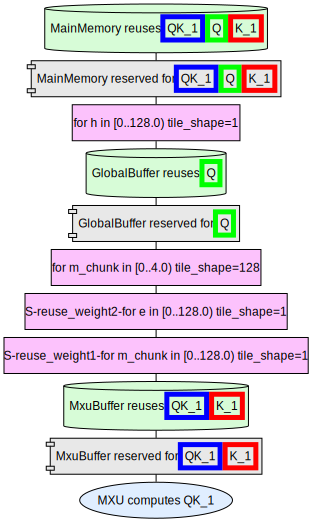

In [7]:
# QK
P_1_QK_results

In [8]:
# QK
print("Total Cycles: ", get_cycles(P_1_QK_results))
print("Total Energy: ", get_energy(P_1_QK_results))
print("MainMemory: ", get_component_energy(P_1_QK_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_QK_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_QK_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_QK_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_QK_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_QK_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_QK_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_QK_results, 'MXU'))

Total Cycles:  1.379564855596982e-05
Total Energy:  0.0005511281280238026
MainMemory:  0.00047638246905989945
GlobalBuffer:  1.294991359900847e-06

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  7.274600929796608e-05
MXU:  7.04643072e-07


In [9]:
# SM
P_1_SM_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/C_16/flash_attention_C_16_SM.yaml"
)
P_1_SM_results = P_1_SM_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running softmax_1: 100%|██████████████████| 4/4 [00:00<00:00, 24.12it/s]
Generating pmapping templates for compute ScalarUnit Einsum max_1: 10it [00:00, 118.79it/s]              | 0/4 [00:00<?, ?it/s]
Generating pmapping templates for compute MXU Einsum max_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum max_1: 0it [00:00, ?it/s]0:00, 111.50it/s]
Generating pmapping templates for compute ScalarUnit Einsum sum_1: 16it [00:00, 112.35it/s]      | 1/4 [00:00<00:00,  5.85it/s]
Generating pmapping templates for compute ScalarUnit Einsum exp_1: 16it [00:00, 111.61it/s]
Generating pmapping templates for compute ScalarUnit Einsum softmax_1: 16it [00:00, 108.38it/s]
Generating pmapping templates for compute MXU Einsum sum_1: 0it [00:00, ?it/s]t/s]
Generating pmapping templates for compute MXU Einsum exp_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum softmax_1: 0it [00:00, ?it/s]
Generati

Einsum max_1 has 10 pmapping jobs:
	0	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [QK_1 in ScalarBuffer] [max_1 in ScalarBuffer] T-m_chunk  ScalarUnit computes max_1
	1	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [max_1 in ScalarBuffer] T-m_chunk  [QK_1 in ScalarBuffer] ScalarUnit computes max_1
	2	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  [QK_1 in GlobalBuffer] S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [QK_1 in ScalarBuffer] [max_1 in ScalarBuffer] T-m_chunk  ScalarUnit computes max_1
	3	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  [QK_1 in GlobalBuffer] S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [max_1 in ScalarBuffer] T-m_chunk  [QK_1 in ScalarBuffer] ScalarUnit computes max_1
	4	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  [max_1 in GlobalBuffer] T-m_chunk  S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [QK_1 in ScalarBuffer] [max_1 in ScalarB

Compressing pmappings: 100%|████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 103.39it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 597.29it/s]


...

Dirty pruning pmappings: 100%|████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 646.29it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 249 -> 249 (100.00% kept) pmappings


Grouping pmappings: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 186.78it/s]


Dirty joining mapping(s) valid & optimal! Returning...


/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:368: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


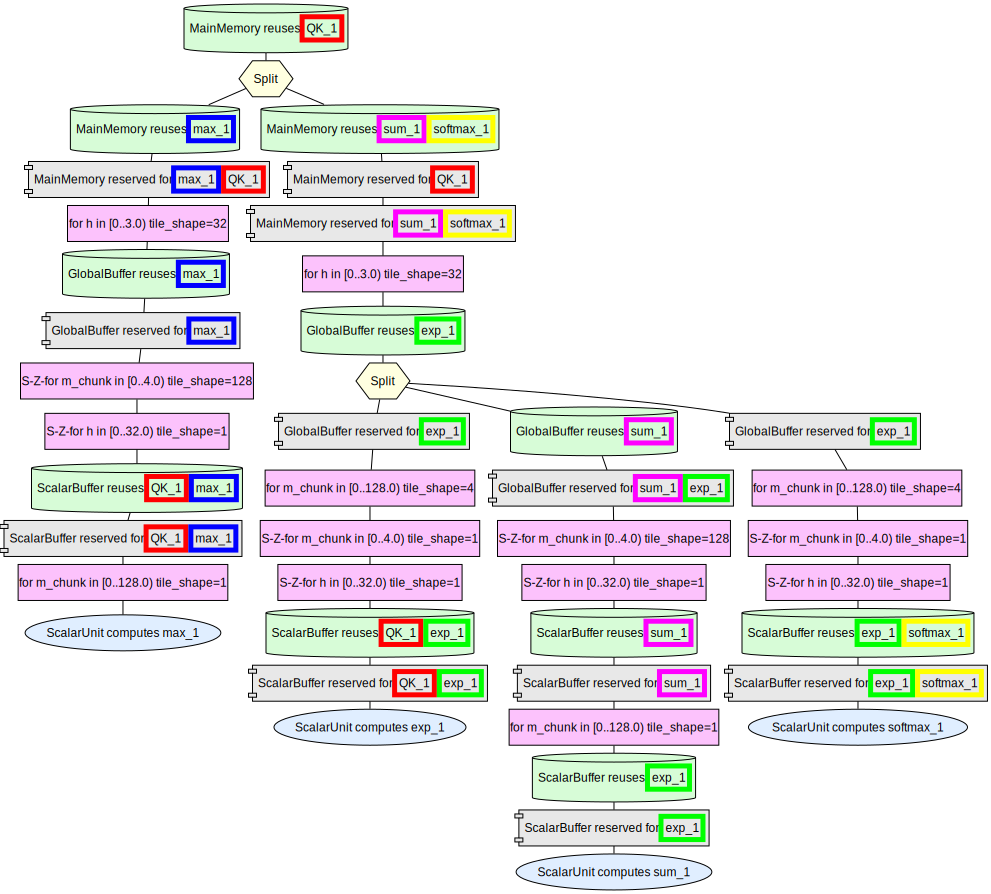

In [10]:
# SM
P_1_SM_results

In [11]:
# SM
print("Total Cycles: ", get_cycles(P_1_SM_results))
print("Total Energy: ", get_energy(P_1_SM_results))
print("MainMemory: ", get_component_energy(P_1_SM_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_SM_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_SM_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_SM_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_SM_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_SM_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_SM_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_SM_results, 'MXU'))

Total Cycles:  1.4628571989305783e-06
Total Energy:  1.2668507034296335e-05
MainMemory:  8.303723286307019e-06
GlobalBuffer:  2.423869517431676e-06

ScalarBuffer:  1.7049845787102252e-06
ScalarUnit:  2.359296e-07

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  0.0
MXU:  0.0


In [12]:
# AV
P_1_AV_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU_AV.yaml",
    "../workloads/C_16/flash_attention_C_16_AV.yaml"
)
P_1_AV_results = P_1_AV_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running AV_1: 100%|███████████████████████| 1/1 [00:00<00:00, 23.43it/s]
Generating jobs:   0%|                                                                                   | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum AV_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 11it [00:00, 104.30it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 22it [00:00, 99.33it/s] 
Generating pmapping templates for compute MXU Einsum AV_1: 32it [00:00, 75.56it/s]

Generating pmapping templates for compute VPU Einsum AV_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum AV_1: 12it [00:00, 112.98it/s]
Generating pmapping templates for compute VPU Einsum AV_1: 32it [00:00, 107.26it/s]
Generating jobs: 100%|████████████████████████████████████████████████████████████

Einsum AV_1 has 64 pmapping jobs:
	0	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [AV_1 in MxuBuffer] T-m_chunk  [V_1 in MxuBuffer] T-m  MXU computes AV_1
	1	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [V_1 in MxuBuffer] T-m  [AV_1 in MxuBuffer] T-m_chunk  MXU computes AV_1
	2	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] S-reuse_weight2-m_chunk  S-reuse_weight1-e  [AV_1 in MxuBuffer] T-m_chunk  [V_1 in MxuBuffer] T-m  MXU computes AV_1
	3	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] T-m_chunk  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [V_1 in MxuBuffer] T-m  [AV_1 in MxuBuffer] T-m_chunk  MXU computes AV_1
	4	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  

Compressing pmappings: 100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 459.55it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1513.10it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=5.50e-04
Final clean join.


Dirty pruning pmappings: 100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1663.75it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|██████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 11491.24it/s]


Dirty joining mapping(s) valid & optimal! Returning...


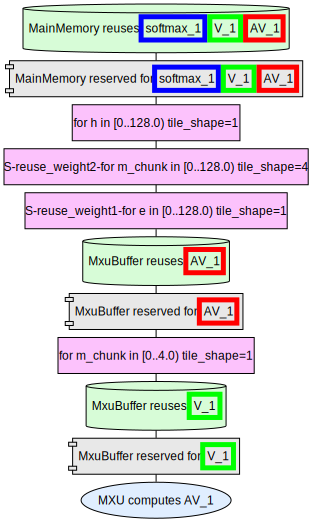

In [13]:
# AV
P_1_AV_results

In [14]:
# AV
print("Total Cycles: ", get_cycles(P_1_AV_results))
print("Total Energy: ", get_energy(P_1_AV_results))
print("MainMemory: ", get_component_energy(P_1_AV_results, 'MainMemory'))
print("MainMemory cycles: ", get_component_cycles(P_1_AV_results, 'MainMemory'))

print("GlobalBuffer: ", get_component_energy(P_1_AV_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_AV_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_AV_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_AV_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_AV_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_AV_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_AV_results, 'MXU'))
print("MXU cycles: ", get_component_cycles(P_1_AV_results, 'MXU'))


Total Cycles:  1.379564855596982e-05
Total Energy:  0.0005498331369719413
MainMemory:  0.00047638247550702825
MainMemory cycles:  1.379564855596982e-05
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  7.274601111695548e-05
MXU:  7.04643072e-07
MXU cycles:  4.876190473623865e-07


In [15]:
# ACC
P_1_ACC_spec = Spec.from_yaml(
    "../arches/tpu_v4i_only_VPU.yaml",
    "../workloads/C_16/flash_attention_C_16_ACC.yaml"
)
P_1_ACC_results = P_1_ACC_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running AV_accum_1: 100%|█████████████████| 1/1 [00:00<00:00, 28.38it/s]
Generating jobs:   0%|                                                                                   | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV_accum_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute VPU Einsum AV_accum_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum AV_accum_1: 16it [00:00, 104.18it/s][A
Generating jobs: 100%|███████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.90it/s]


Einsum AV_accum_1 has 16 pmapping jobs:
	0	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	1	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  [AV_0 in GlobalBuffer] S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	2	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	3	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  [AV_accum_1 in GlobalBuffer] S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	4	[AV_accum_1 in MainMemory] [AV_1 in MainMe

Compressing pmappings: 100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 410.52it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1618.17it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=2.13e-06
Final clean join.


Dirty pruning pmappings: 100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1678.39it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|██████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 11915.64it/s]


Dirty joining mapping(s) valid & optimal! Returning...


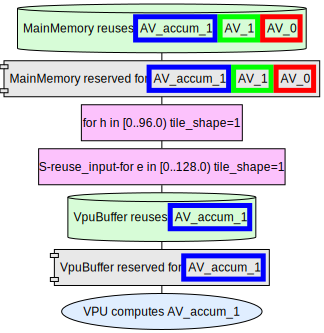

In [16]:
# ACC
P_1_ACC_results

In [17]:
# ACC
print("Total Cycles: ", get_cycles(P_1_ACC_results))
print("Total Energy: ", get_energy(P_1_ACC_results))
print("MainMemory: ", get_component_energy(P_1_ACC_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_ACC_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_ACC_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_ACC_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_ACC_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_ACC_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_ACC_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_ACC_results, 'MXU'))

Total Cycles:  9.142857493316114e-08
Total Energy:  2.1304442731169964e-06
MainMemory:  2.0732313448751486e-06
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  5.328076824184791e-08
VPU:  3.93216e-09

MxuBuffer:  0.0
MXU:  0.0


In [18]:
# Gathered Results
print("QK Total Cycles: ", get_cycles(P_1_QK_results))
print("QK Total Energy: ", get_energy(P_1_QK_results))
print("SM Total Cycles: ", get_cycles(P_1_SM_results))
print("SM Total Energy: ", get_energy(P_1_SM_results))
print("AV Total Cycles: ", get_cycles(P_1_AV_results))
print("AV Total Energy: ", get_energy(P_1_AV_results))
print("ACC Total Cycles: ", get_cycles(P_1_ACC_results))
print("ACC Total Energy: ", get_energy(P_1_ACC_results))

QK Total Cycles:  1.379564855596982e-05
QK Total Energy:  0.0005511281280238026
SM Total Cycles:  1.4628571989305783e-06
SM Total Energy:  1.2668507034296335e-05
AV Total Cycles:  1.379564855596982e-05
AV Total Energy:  0.0005498331369719413
ACC Total Cycles:  9.142857493316114e-08
ACC Total Energy:  2.1304442731169964e-06


In [24]:
# Total Pipeline Results
print("Total Pipeline Cycles: ", 16*(get_cycles(P_1_QK_results)+get_cycles(P_1_SM_results)+get_cycles(P_1_AV_results)+get_cycles(P_1_ACC_results)))
print("Total Pipeline Energy: ", 16*(get_energy(P_1_QK_results)+get_energy(P_1_SM_results)+get_energy(P_1_AV_results)+get_energy(P_1_ACC_results)))

Total Pipeline Cycles:  0.00046632932617285405
Total Pipeline Energy:  0.017852163460850515


# P = 2

In [25]:
# Total Pipeline Cycles
QK_cycles = get_cycles(P_1_QK_results)
QK_SM_cycles = max(get_cycles(P_1_QK_results), get_cycles(P_1_SM_results))
AV_SM_cycles = max(get_cycles(P_1_AV_results), get_cycles(P_1_SM_results))
AV_ACC_cycles = max(get_cycles(P_1_AV_results), get_cycles(P_1_ACC_results))
QK_ACC_cycles = max(get_cycles(P_1_QK_results), get_cycles(P_1_ACC_results))
ACC_cycles = get_cycles(P_1_ACC_results)

P_2_cycles = QK_cycles+8*QK_SM_cycles+8*AV_SM_cycles+8*AV_ACC_cycles+6*QK_ACC_cycles+ACC_cycles

print("Total Pipeline Cycles: ", P_2_cycles)

Total Pipeline Cycles:  0.00042775653380999756


In [28]:
# Total Pipeline Energy

QK_energy = get_energy(P_1_QK_results)
QK_SM_energy = max(get_energy(P_1_QK_results), get_energy(P_1_SM_results))
AV_SM_energy = max(get_energy(P_1_AV_results), get_energy(P_1_SM_results))
AV_ACC_energy = max(get_energy(P_1_AV_results), get_energy(P_1_ACC_results))
QK_ACC_energy = max(get_energy(P_1_QK_results), get_energy(P_1_ACC_results))
ACC_energy = get_energy(P_1_ACC_results)

P_2_energy = QK_energy+8*QK_SM_energy+8*AV_SM_energy+8*AV_ACC_energy+6*QK_ACC_energy+ACC_energy

print("Total Pipeline Energy: ", P_2_energy)

Total Pipeline Energy:  0.017066382556181217


# P = 3

In [27]:
# Total Pipeline Cycles
QK_cycles = get_cycles(P_1_QK_results)
SM_cycles = get_cycles(P_1_SM_results)
AV_cycles = get_cycles(P_1_AV_results)
ACC_cycles = get_cycles(P_1_ACC_results)
QK_SM_cycles = max(get_cycles(P_1_QK_results), get_cycles(P_1_SM_results))
AV_SM_cycles = max(get_cycles(P_1_AV_results), get_cycles(P_1_SM_results))
AV_ACC_cycles = max(get_cycles(P_1_AV_results), get_cycles(P_1_ACC_results))
QK_ACC_cycles = max(get_cycles(P_1_QK_results), get_cycles(P_1_ACC_results))

P_3_cycles = QK_cycles+SM_cycles+AV_cycles+ACC_cycles+10*QK_SM_cycles+5*AV_SM_cycles+10*AV_ACC_cycles+5*QK_ACC_cycles

print("Total Pipeline Cycles: ", P_3_cycles)

Total Pipeline Cycles:  0.00044301503956489796


In [29]:
# Total Pipeline Energy
QK_energy = get_energy(P_1_QK_results)
SM_energy = get_energy(P_1_SM_results)
AV_energy = get_energy(P_1_AV_results)
ACC_energy = get_energy(P_1_ACC_results)
QK_SM_energy = max(get_energy(P_1_QK_results), get_energy(P_1_SM_results))
AV_SM_energy = max(get_energy(P_1_AV_results), get_energy(P_1_SM_results))
AV_ACC_energy = max(get_energy(P_1_AV_results), get_energy(P_1_ACC_results))
QK_ACC_energy = max(get_energy(P_1_QK_results), get_energy(P_1_ACC_results))

P_3_energy = QK_energy+SM_energy+AV_energy+ACC_energy+10*QK_SM_energy+5*AV_SM_energy+10*AV_ACC_energy+5*QK_ACC_energy

print("Total Pipeline Energy: ", P_3_energy)

Total Pipeline Energy:  0.017630179191239315
